<a href="https://colab.research.google.com/github/Yadav1218/colab/blob/main/group%20project/XGBoost_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XGBoost Train

## 資料前處理

### 升級scikit-learn至最新版本，確保函式皆可使用

In [ ]:
%pip install --upgrade scikit-learn

### requirements.txt(維持套件版本/讀取原套件版本)

In [ ]:
# 將目前的python環境變數存成requirements
%pip freeze > requirements.txt

In [ ]:
# 將目前的python環境變數存成requirements
%pip install -r requirements.txt

### 載入套件

In [ ]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
class AutoPreprocess:
    def __init__(self):
        self.scaler = {}
        self.fillna_value = {}
        self.onehotencode_value = {}
        self.field_names = []
        self.final_field_names = []

    def fit(self, data, field_names):
        self.__init__()
        self.field_names = field_names

        for fname in field_names:
            #自動補空值
            if (data[fname].dtype == object) or (data[fname].dtype == str): #字串型態欄位
                self.fillna_value[fname] = data[fname].mode()[0] #補眾數
                # self.fillna_value[fname] = 'np.nan'
                # self.fillna_value[fname] = np.nan # 維持空值
            elif data[fname].dtype == bool: #布林型態
                self.fillna_value[fname] = data[fname].mode()[0] #補眾數
            else: # 數字型態
                self.fillna_value[fname] = data[fname].median()  #補中位數

            #自動尺度轉換(scaling)
            if (data[fname].dtype == object) or (data[fname].dtype == str): #字串型態欄位
                pass #不用轉換
            elif data[fname].dtype == bool: #布林型態
                pass #不用轉換
            else: # 數字型態
                vc = data[fname].value_counts()
                if data[fname].isin([0, 1]).all(): #當數值只有0跟1
                    pass #不用轉換
                elif pd.api.types.is_integer_dtype(data[fname]) and data[fname].nunique() <= 10: #是否簡單的整數型類別且數量小於10
                    self.scaler[fname] = MinMaxScaler()
                    self.scaler[fname].fit(data[[fname]])
                else: #其他的數字型態
                    self.scaler[fname] = StandardScaler()
                    self.scaler[fname].fit(data[[fname]])


            #自動編碼
            if (data[fname].dtype == object) or (data[fname].dtype == str): #字串型態欄位, onehotencode
                field_value = data[fname].value_counts().index
                self.onehotencode_value[fname] = field_value
                for value in field_value:
                    fn = fname+"_"+value
                    # data[fn] = (data[fname] == value).astype('int8')
                    self.final_field_names.append(fn)
            elif data[fname].dtype == bool: #布林型態 轉成0跟1
                # data[fname] = data[fname].astype(int)
                self.final_field_names.append(fname)
            else: # 數字型態 不用重新編碼
                self.final_field_names.append(fname)

        return

    def transform(self, data):
        #如果輸入的data是dict，要先轉成dataframe
        if isinstance(data, dict):
            for fname in self.field_names:
                if fname in data:
                    data[fname] = [data[fname]]
                else:
                    data[fname] = [np.nan]
            data = pd.DataFrame(data)
        else: #將資料複製一份，不修改原本的資料
            data = data.copy()

        for fname in self.field_names:
            #自動補空值
            if data[fname].isnull().any(): #有空值
                # if fname in self.fillna_value:
                    data[fname] = data[fname].fillna(self.fillna_value[fname])


            #自動尺度轉換(scaling)
            if fname in self.scaler:
                data[fname] = self.scaler[fname].transform(data[[fname]])

            #自動編碼
            if (data[fname].dtype == object) or (data[fname].dtype == str): #字串型態欄位, onehotencode
                if fname in self.onehotencode_value:
                    field_value = self.onehotencode_value[fname]
                for value in field_value:
                    fn = fname+"_"+value
                    data[fn] = (data[fname] == value).astype('int8')
            elif data[fname].dtype == bool: #布林型態 轉成0跟1
                data[fname] = data[fname].astype(int)
            else: # 數字型態 不用重新編碼
                pass
        return data[self.final_field_names]

    def save(self, file_name):
        with open(file_name, "wb") as f:
            pickle.dump(self, f)

    @staticmethod
    def load(file_name):
        with open(file_name, "rb") as f:
            return pickle.load(f)

## 載入資料(local寫入自己路徑)

In [ ]:
#載入訓練用資料
import pandas as pd
import numpy as np

#local輸入自己電腦的路徑，以下會統一替代

#local="C:/Users/User/vscode/python/團體專題project/"
local="../content/drive/MyDrive/"
data = pd.read_csv(local+"rakuya_train_80.csv")
data.head()

,Unnamed: 0,物件編號,物件網址,每月租金,出租房型,房屋型態,坪數,每坪單價,屋齡,可否開伙,...,濾水器,網路,椅子,電磁爐,電話,茶几,雙人(以上)沙發,瓦斯爐,第四台,郵遞區號
0,771,0a7be329962419a,https://www.rakuya.com.tw/rent/rent_item?ehid=...,39000,整層住家,電梯大廈,35.53,1098,99.0,1,...,0,0,0,0,0,0,0,0,0,241
1,1581,014ccc305182125,https://www.rakuya.com.tw/rent/rent_item?ehid=...,40000,整層住家,公寓,25.81,1550,99.0,1,...,0,0,0,1,0,0,0,0,0,115
2,2031,004821301853354,https://www.rakuya.com.tw/rent/rent_item?ehid=...,30000,整層住家,電梯大廈,13.09,2292,99.0,1,...,0,0,1,0,0,0,1,0,0,104
3,846,087c76304035499,https://www.rakuya.com.tw/rent/rent_item?ehid=...,29000,整層住家,電梯大廈,63.32,458,3.1,1,...,0,0,0,0,0,0,0,0,0,251
4,2733,0dce3e22711418d,https://www.rakuya.com.tw/rent/rent_item?ehid=...,130000,整層住家,電梯大廈,88.42,1470,99.0,1,...,1,0,1,0,0,1,1,1,0,103


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data.columns = data.columns.str.strip()
data.columns

Index(['Unnamed: 0', '物件編號', '物件網址', '每月租金', '出租房型', '房屋型態', '坪數', '每坪單價',
       '屋齡', '可否開伙', '可否養寵物', '管理員', '車位', '烤箱', '液晶電視', '微波爐', '洗衣機', '書架',
       '天然瓦斯', '電風扇', '雙人床', '單人床', '餐椅', '冰箱', '冷氣', '單人沙發', '衣櫥', '烘衣機',
       '脫水機', '熱水器', '餐桌', '飲水機', '電熱水器', '傳統電視', '置物櫃', '書桌', '濾水器', '網路',
       '椅子', '電磁爐', '電話', '茶几', '雙人(以上)沙發', '瓦斯爐', '第四台', '郵遞區號'],
      dtype='object')

In [ ]:
data = data.drop(columns=["Unnamed: 0", "物件編號", "物件網址"])

In [ ]:
data.shape

(2657, 43)

郵遞區號, 出租房型, 房屋型態, 坪數, 屋齡, 可否開伙, 可否養寵物, 管理員, 車位

In [ ]:
#ap = AutoPreprocess()
#ap.fit(data, ['郵遞區號', '出租房型', '房屋型態', '坪數', '屋齡', '可否開伙', '可否養寵物', '管理員', '車位'])
#ap.save(local+"preprocess.bin")
#X = ap.transform(data)
#y = data['每坪單價']

In [ ]:
# X = data.drop(columns=["每月租金", "每坪單價"])  # 避免資料洩漏
# y = data["每坪單價"]
# X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

X = data.drop(columns=["每月租金"])
y = data["每月租金"]
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

### 變動參數-group

In [ ]:

# 分群定義
groups = {
    "家具": ['雙人床', '單人床', '書桌', '餐桌', '餐椅', '單人沙發', '雙人(以上)沙發', '茶几', '椅子', '衣櫥', '置物櫃', '書架'],
    "家電": ['液晶電視', '傳統電視', '微波爐', '洗衣機', '烘衣機', '脫水機', '冰箱', '冷氣', '電風扇', '電磁爐', '熱水器', '電熱水器', '飲水機'],
    "設施": ['管理員', '車位', '網路', '電話', '第四台'],
    "能源": ['瓦斯爐', '天然瓦斯'],
    "允許": ['可否開伙', '可否養寵物']
}

# 建立新欄位：群組化特徵
data_grouped = data.copy()
for group_name, group_fields in groups.items():
    data_grouped[f"設備群_{group_name}"] = data_grouped[group_fields].sum(axis=1)

# 指定特徵欄位
selected_features = ['出租房型', '房屋型態', '坪數', '屋齡', '郵遞區號'] + [f"設備群_{g}" for g in groups]

# 前處理
ap_grouped = AutoPreprocess()
ap_grouped.fit(data_grouped[selected_features], selected_features)
X = ap_grouped.transform(data_grouped[selected_features])

In [ ]:
X.columns = X.columns.str.strip()
X.columns

Index(['出租房型_整層住家', '出租房型_獨立套房', '出租房型_分租套房', '出租房型_雅房', '房屋型態_電梯大廈',
       '房屋型態_公寓', '房屋型態_華廈', '房屋型態_透天厝', '房屋型態_其他', '房屋型態_別墅', '房屋型態_樓中樓',
       '房屋型態_套房', '房屋型態_雅房', '坪數', '屋齡', '郵遞區號', '設備群_家具', '設備群_家電', '設備群_設施',
       '設備群_能源', '設備群_允許'],
      dtype='object')

## 開始訓練

### 模型選擇(可選)(XGBoost)

In [ ]:
# 下載XGBoost套件
%pip install xgboost scikit-learn

## 20訓練/80驗證

### 下載套件

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, make_scorer, root_mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import pickle

### 切分訓練集/驗證集 與 建立DMatrix

In [ ]:
# 切分資料，訓練集/驗證集 : 8/2
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

#創建XGBoost特有的數據結構DMatrix
train_data = xgb.DMatrix(X_train, label=y_train)

### XGBoost內建xgb.cv()尋找最佳迭代輪數(n_estimators)

In [ ]:
# 設置模型參數
params = {
    'objective': 'reg:squarederror',  # 目標是迴歸
    'max_depth': 4,  # 決策樹的最大深度，建議3~7
    'eta': 0.1,  # 學習率，0.01 ~ 0.3，小會穩定但需更多輪
    'eval_metric': 'rmse'  # 用來衡量模型的準確度
}

# 設置交叉驗證的參數
num_round = 300  # 訓練的迭代次數
cv_results = xgb.cv(
    params,               # 參數設置
    train_data,           # 訓練數據
    num_round,            # 訓練的迭代次數
    nfold=5,              # 進行 5-fold 交叉驗證
    early_stopping_rounds=10,  # 早停策略，10輪內如果性能未提升則停止訓練
    as_pandas=True,       # 返回 pandas DataFrame 格式的結果
    seed=42               # 隨機種子
)

# 顯示交叉驗證結果
print(cv_results)

# 找出最佳的迭代次數
best_round = cv_results['test-rmse-mean'].idxmin()
print("最佳迭代次數:", best_round)


### 內建 xgb.cv()

In [ ]:
final_model = xgb.train(
    params=params,
    dtrain=train_data,
    num_boost_round=best_round
)

# === 預測（注意要跟 DMatrix 綁定） ===
y_train_pred = final_model.predict(train_data)
y_valid_pred = final_model.predict(xgb.DMatrix(X_valid))

# 計算評估指標（直接用 y_train 和 y_valid）
print("\n [訓練集結果]")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"MAE : {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"R²  : {r2_score(y_train, y_train_pred):.4f}")

print("\n [驗證集結果]")
print(f"RMSE: {np.sqrt(mean_squared_error(y_valid, y_valid_pred)):.2f}")
print(f"MAE : {mean_absolute_error(y_valid, y_valid_pred):.2f}")
print(f"R²  : {r2_score(y_valid, y_valid_pred):.4f}")

### 最佳輪數固定 n_estimators

In [ ]:
param_dist = {
    'max_depth': [3, 4, 5, 6],  # 決策樹的最大深度(防過擬合)
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # 學習率，越小越慢但穩
    'subsample': [0.6, 0.8, 1.0],  # 每棵樹用多少比例的樣本(防過擬合)
    'colsample_bytree': [0.6, 0.8, 1.0],  # 每棵樹使用多少比例的特徵
    'reg_alpha': [0, 0.1, 0.5],  # L1 正則化（壓縮不重要特徵）
    'reg_lambda': [1, 2, 3]  # L2 正則化（防止模型權重爆炸）
    }

scorer = make_scorer(mean_squared_error, greater_is_better=False)

### RandomizedSearchCV調參

In [ ]:
# 建立模型
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_round,
    random_state=42
)

# 使用RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,  # 要被調參的模型
    param_distributions=param_dist,  # 搜尋的超參數
    n_iter=20, #抽樣幾組參數組合，精準vs.執行時間
    cv=3, # fold，幾折交叉驗證（Cross-validation folds）
    scoring=scorer, # 指標來判斷「哪組參數比較好
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 執行搜尋
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_valid_pred = best_model.predict(X_valid)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_pred = np.sqrt(mean_squared_error(y_valid, y_valid_pred))

# 預測與評估
print("\n[訓練集]")
print("RMSE:", rmse_train)
print("R2:", r2_score(y_train, y_train_pred))
print(f"MAE : {mean_absolute_error(y_valid, y_valid_pred):.2f}")

print("\n[驗證集]")
print("RMSE:", rmse_pred)
print("R2:", r2_score(y_valid, y_valid_pred))
print(f"MAE : {mean_absolute_error(y_valid, y_valid_pred):.2f}")

## 儲存RandomizedSearchCV後最佳模型及參數

In [ ]:
print(type(best_model))

<class 'xgboost.sklearn.XGBRegressor'>


In [ ]:
# 正確儲存模型（確保存在 local 目錄）
# booster = best_model.get_booster()
# booster.save_model("xgb_visual_model.xgb")

with open("xgb_best_params.pkl", "wb") as f:
    pickle.dump(random_search.best_params_, f)

## XGBoost 特徵重要性

### 設定字體Windows/Mac/Colab

In [ ]:
import platform
import matplotlib.pyplot as plt
import matplotlib
if platform.system() == "Windows":
    matplotlib.rcParams['font.family'] = 'Microsoft JhengHei'
elif platform.system() == "Darwin":  # macOS
    matplotlib.rcParams['font.family'] = 'Heiti TC'
else:  # 例如 Colab / Linux
    matplotlib.rcParams['font.family'] = 'Noto Sans CJK TC'
matplotlib.rcParams['axes.unicode_minus'] = False  # 負號正常顯示

/tmp/ipython-input-31-1245840030.py:8: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-31-1245840030.py:8: UserWarning: Glyph 31199 (\N{CJK UNIFIED IDEOGRAPH-79DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-31-1245840030.py:8: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-31-1245840030.py:8: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-31-1245840030.py:8: UserWarning: Glyph 38597 (\N{CJK UNIFIED IDEOGRAPH-96C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-31-1245840030.py:8: UserWarning: Glyph 29544 (\N{CJK UNIFIED IDEOGRAPH-7368}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-31-1245840030.py:8: UserWarning: Glyph 31435 (\N{CJK UNIFIED IDEOGRAP

<Figure size 1000x800 with 0 Axes>

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31199 (\N{CJK UNIFIED IDEOGRAPH-79DF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38597 (\N{CJK UNIFIED IDEOGRAPH-96C5}) missing from font(s) DejaVu Sans.
  fig.canvas

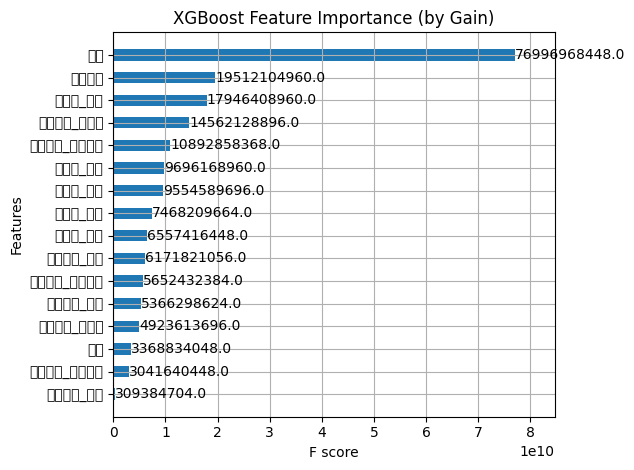

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# 畫出特徵重要性（用 gain 來評估）
plt.figure(figsize=(10, 8))
plot_importance(best_model, importance_type='gain', max_num_features=20, height=0.5)
plt.title("XGBoost Feature Importance (by Gain)")
plt.tight_layout()
plt.show()


/tmp/ipython-input-32-2363746244.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
/tmp/ipython-input-32-2363746244.py:19: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-32-2363746244.py:19: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-32-2363746244.py:19: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-32-2363746244.py:19: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-32-2363746244.py:19: UserWarning: Glyph 25976 (\N{CJK UNIFIED ID

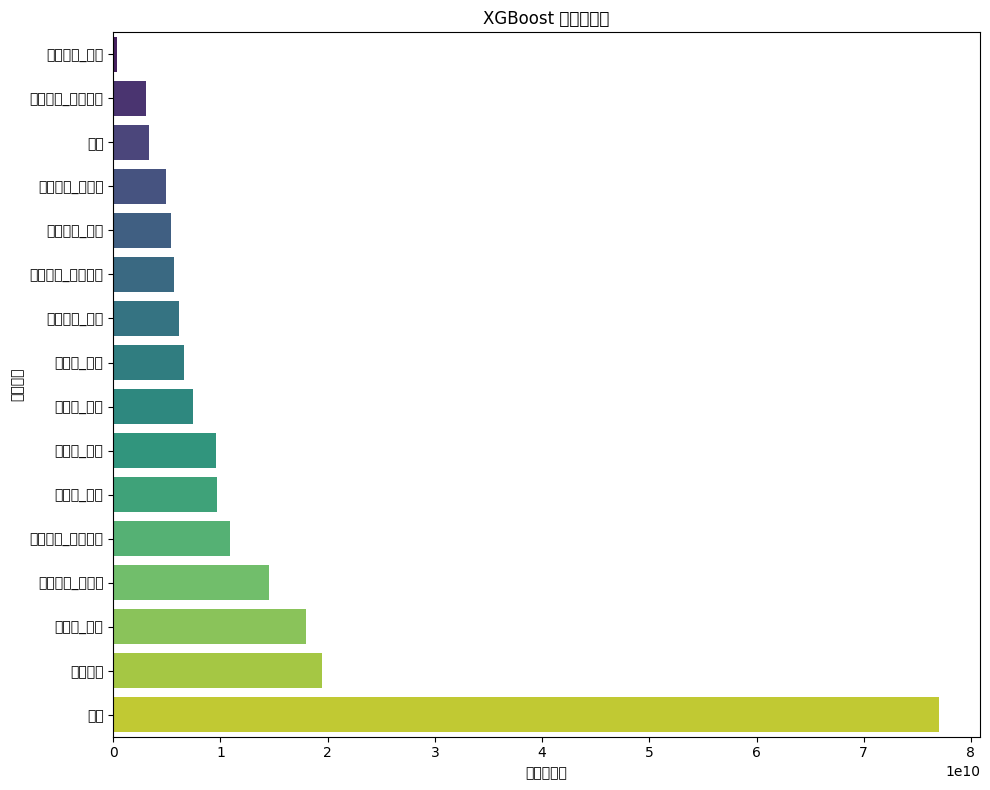

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 取出特徵重要性（以 gain 為準）
importance_dict = best_model.get_booster().get_score(importance_type='gain')

# 轉為 DataFrame 並排序
importance_df = pd.DataFrame(importance_dict.items(), columns=['feature', 'importance'])
importance_df = importance_df.sort_values(by='importance', ascending=True)

# 畫出熱力風格橫條圖
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')

plt.title('XGBoost 特徵重要性')
plt.xlabel('重要性分數')
plt.ylabel('特徵名稱')
plt.tight_layout()
plt.show()
